### Main figures

Everything reads from the MAR outputs (1980–2100, SSP5-8.5) forced by
CNRM-CM6-1, IPSL-CM6A-LR, MPI-ESM1-2-HR and UKESM1-0-LL, run twice: `DS` with
the drifting-snow scheme on, `nDS` with it off. (=or wind-driven snow, WDS/nWDS) Also needed IMBIE-2 basin shapefile.  

`MAR_DATA_DIR` and `IMBIE_SHP` before running the codes.

Two warming thresholds (T_cross and T_moa) are used throughout, both expressed as warming above
1981–2010 over grounded ice in the 350–700 m elevation band:

- `T_MOA` — liquid water production (ME + RF) reaches 70% of net accumulation
  (SF − ER − SU)
- `T_CROSS` — runoff overtakes snow transport (wind-driven snow) as the dominant ablation process

Relative ablation is normalised by the precipitation of the nDS run:

```
rel_ER = 100 * [P_nDS - (SF_DS + RF_DS - ER_DS)] / P_nDS
rel_RU = 100 * RU_DS / P_nDS
```

Base setup adapted from the code created by Charles Amory. (full script uploaded as multiproj.pynb)

Note: before we used 'drifting snow' and 'snow transport' which is now referred to as 'wind-driven snow'. In the paper we renamed DS and nDs to WDS and nWDS

## Setup

In [ ]:
import os
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
import seaborn as sns
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from scipy import stats
from scipy.optimize import curve_fit
from shapely.geometry import LineString

warnings.filterwarnings("ignore")
sns.set_style("white")


DATA_DIR = Path(os.environ.get("MAR_DATA_DIR", "/Users/dashakan/Desktop/scripts_AIS"))
SHP_PATH = Path(os.environ.get(
    "IMBIE_SHP",
    "/Users/dashakan/Downloads/ANT_Basins_IMBIE2_v1.6/ANT_Basins_IMBIE2_v1.6.shp")) # change the paths on your local machine here
FIG_DIR = Path(os.environ.get("FIG_DIR", "figures"))
TAB_DIR = Path(os.environ.get("TABLE_DIR", "tables"))
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

CST_FILE = DATA_DIR / "MARcst-AN35km-176x148.cdf2"


REF0, REF1 = "1981-01-01", "2010-01-01"
FUT0, FUT1 = "2071-01-01", "2100-01-01"
YEARS = pd.date_range("1980-01-01", "2100-01-01", freq="YS")

RESOLUTION = 35_000        # m, MAR grid spacing
BAND = (350, 700)          # grounded-ice elevation band, m
MOA_THRESHOLD = 0.7
RISK_THRESHOLD = 6.0       # basin at risk if all models reach T_MOA below this


MODELS = {"CNRM": "goldenrod", "IPSL": "forestgreen",
          "MPI": "firebrick", "UKM": "navy"}
LONG_NAME = {"CNRM": "MAR-CNRM", "IPSL": "MAR-IPSL",
             "MPI": "MAR-MPI", "UKM": "MAR-UKESM"}
FILE_KEY = {"CNRM": "CNRM", "IPSL": "IPL", "MPI": "MPI", "UKM": "UKM"}

BASINS = ["A-Ap", "Ap-B", "B-C", "C-Cp", "Cp-D", "D-Dp", "Dp-E", "E-Ep", "Ep-F",
          "F-G", "G-H", "H-Hp", "Hp-I", "I-Ipp", "Ipp-J", "J-Jpp", "Jpp-K", "K-A"]

In [8]:
cst = xr.open_dataset(CST_FILE, decode_times=False, engine="netcdf4")


ais = cst["AIS"].where(cst["AIS"] > 0)
grd = cst["GROUND"].where(cst["GROUND"] > 30)
shf = cst["ICE"].where((cst["ICE"] > 30) & (cst["GROUND"] < 50) & (cst["ROCK"] < 30))
grd_msk = ais * grd * cst["AREA"] / 100
shf_msk = shf * cst["AREA"] / 100

SH = cst["SH"].values.astype(float)
AREA_2D = cst["AREA"].values.astype(float)
ICE = cst["ICE"].values > 0
GROUND = cst["GROUND"].values > 0
SHELF = ICE & ~GROUND
ais_mask = cst["AIS"].values > 0
lsm = cst["AIS"].values < 1

grd_frac = np.where(ais_mask & (cst["GROUND"].values > 30),
                    cst["GROUND"].values / 100.0, 0.0)
band_mask = np.isfinite(SH) & (SH >= BAND[0]) & (SH < BAND[1])
topo_grd = np.where(GROUND, np.where(ICE, SH, np.nan), np.nan)

x2D, y2D = np.meshgrid(cst["X"], cst["Y"])
assert x2D.shape == SH.shape, "plotting grid does not match the MAR field shape"

# MAR ships X/Y in km; EPSG:3031 wants metres.
KM_TO_M = 1000.0 if np.nanmax(np.abs(x2D)) < 1e5 else 1.0
x2m, y2m = x2D * KM_TO_M, y2D * KM_TO_M


def preprocess(ds):
  
    for key in ("SECTOR", "SECTOR1_1"):
        try:
            ds = ds.sel({key: 1})
        except (KeyError, ValueError):
            pass
    try:
        ds["TT"] = ds["TT"].sel(ATMLAY=0.99973)
    except (KeyError, ValueError):
        pass
    try:
        ds = ds.rename_dims({"x": "X", "y": "Y"})
    except ValueError:
        pass
    return ds


def open_mar(run, model):
    path = DATA_DIR / f"year-MAR-{run}_{FILE_KEY[model]}-1980-2100.nc"
    ds = xr.open_mfdataset(str(path), decode_times=False,
                           preprocess=preprocess, engine="netcdf4")
    ds["TIME"] = YEARS
    return ds


DS = {m: open_mar("DS", m) for m in MODELS}
NDS = {m: open_mar("nDS", m) for m in MODELS}

In [ ]:
gdf = gpd.read_file(SHP_PATH)
region_col = next(c for c in ("Subregion", "SUBREGION", "Regions", "Region", "NAME", "Name")
                  if c in gdf.columns)
gdf = gdf.to_crs("EPSG:3031")[[region_col, "geometry"]].dropna()
gdf[region_col] = (gdf[region_col].astype(str).str.strip()
                   .str.replace("[\u2013\u2014]", "-", regex=True))

gdf = gdf.dissolve(by=region_col, as_index=False).rename(columns={region_col: "Subregion"})


def label_grid(scale):
    pts = gpd.GeoDataFrame(
        {"i": np.arange(x2D.size)},
        geometry=gpd.points_from_xy((x2D * scale).ravel(), (y2D * scale).ravel()),
        crs="EPSG:3031")
    hit = (gpd.sjoin(pts, gdf, how="left", predicate="within")
           .groupby("i", sort=False)["Subregion"].first())
    out = np.full(x2D.size, None, dtype=object)
    out[hit.index.to_numpy(dtype=int)] = hit.to_numpy(dtype=object)
    return out.reshape(x2D.shape)



trials = []
for scale in (KM_TO_M, 1.0, 0.001):
    arr = label_grid(scale)
    on_ground = pd.notna(arr) & (grd_frac > 0)
    n = int(pd.Series(arr[on_ground]).nunique()) if on_ground.any() else 0
    trials.append((n, scale, arr))
n_found, COORD_SCALE, subreg = max(trials, key=lambda t: t[0])

if n_found < 15:
    raise RuntimeError(
        f"basin assignment failed: {n_found} basins over grounded ice. "
        "Check x2D/y2D units, axis order and shapefile CRS.")

present = [b for b in BASINS if np.any(((subreg == b) & band_mask & (grd_frac > 0)))]


In [10]:
def flat(da):
    """Drop every dimension that is not TIME, Y or X."""
    extra = [d for d in da.dims if d not in ("TIME", "Y", "X")]
    if extra:
        da = da.isel({d: 0 for d in extra}, drop=True)
    return da.reset_coords(drop=True).transpose("TIME", "Y", "X")


def weights(basin, mask=None):
    """Ice-fraction and projection weights for one basin inside an elevation band."""
    m = (subreg == basin) & (band_mask if mask is None else mask) & (grd_frac > 0)
    return grd_frac * m.astype(float) * AREA_2D


def aw_mean(da, w):
    """Area-weighted spatial mean, one value per year."""
    V = np.asarray(flat(da).values, dtype=float)
    out = np.full(V.shape[0], np.nan)
    for t in range(V.shape[0]):
        ok = np.isfinite(V[t]) & np.isfinite(w) & (w > 0)
        if ok.any():
            out[t] = np.sum(V[t][ok] * w[ok]) / np.sum(w[ok])
    return out


def tt_anomaly(ds, ref=None):
    """TT relative to the 1981-2010 mean of `ref` (defaults to the run itself)."""
    tt = flat(ds["TT"])
    base = tt if ref is None else flat(ref["TT"])
    return tt - base.sel(TIME=slice(REF0, REF1)).mean("TIME")


def moa_num(ds):
    """Liquid water production, ME + RF."""
    return flat(ds["ME"] + ds["RF"])


def moa_den(ds, run="DS"):
    """Net accumulation: SF - ER - SU with drifting snow, SF - SU without."""
    return flat(ds["SF"] - ds["ER"] - ds["SU"]) if run == "DS" else flat(ds["SF"] - ds["SU"])


def moa_ratio(ds, run="DS"):
    num, den = moa_num(ds), moa_den(ds, run)
    return xr.where(den > 0, num / den, np.nan)


def _mono_exp(x, a, b):
    return a * np.exp(b * x)


def _power_law(x, a, b):
    return a * np.power(x, b)


def fit_wessem(x, num, den, threshold=MOA_THRESHOLD, n_fit=300, extend=6.0):
    """
    fits are adopted from van Wessem (2023)

    Exponential for ME + RF, power law for net accumulation.
    """
    ok = np.isfinite(x) & np.isfinite(num) & np.isfinite(den)
    if ok.sum() < 10:
        return None
    x, num, den = x[ok], num[ok], den[ok]
    order = x.argsort()
    x, num, den = x[order], num[order], den[order]

    try:
        p_num, cov_num = curve_fit(_mono_exp, x, num,
                                   bounds=([0, 0], [1e6, 2]), maxfev=20000)
    except Exception:
        return None
    se_num = np.sqrt(np.diag(cov_num))

    pos = den > 0
    if pos.sum() < 10:
        return None
    shift = x[pos].min() - 0.1
    try:
        p_den, cov_den = curve_fit(_power_law, x[pos] - shift, den[pos],
                                   p0=[1, 0.5], bounds=([0, 0], [1e6, 10]), maxfev=20000)
    except Exception:
        return None
    se_den = np.sqrt(np.diag(cov_den))

    xs = np.linspace(x.min(), x.max() + extend, n_fit)
    ys_num = _mono_exp(xs, *p_num)
    ys_den = _power_law(xs - shift, *p_den)
    moa_line = threshold * ys_den

    try:
        hit = LineString(np.c_[xs, ys_num]).intersection(LineString(np.c_[xs, moa_line]))
        if hit.is_empty:
            t_moa = np.nan
        else:
            t_moa = list(hit.geoms)[0].x if hit.geom_type == "MultiPoint" else hit.x
        if np.isfinite(t_moa) and t_moa > xs.max():
            t_moa = np.nan
    except Exception:
        t_moa = np.nan

    return dict(x=xs, num_fit=ys_num, den_fit=ys_den, moa_line=moa_line,
                num_lo=_mono_exp(xs, p_num[0] - se_num[0], p_num[1]),
                num_hi=_mono_exp(xs, p_num[0] + se_num[0], p_num[1]),
                den_lo=_power_law(xs - shift, p_den[0] - se_den[0], p_den[1]),
                den_hi=_power_law(xs - shift, p_den[0] + se_den[0], p_den[1]),
                T_moa=t_moa)


FIELDS = {m: {"TT_ano": tt_anomaly(DS[m]), "NUM": moa_num(DS[m]), "DEN": moa_den(DS[m])}

          for m in MODELS}

### Figure 1a — surface ablation as % of precipitation

Evolution of three ablation terms till 2100, each relative to the precipitation of
the nDS run, for grounded ice and ice shelves. Lines are the four-model mean,
shading is ±1.64 standard deviations. This plot is produced based on the code written by Charles Amory.

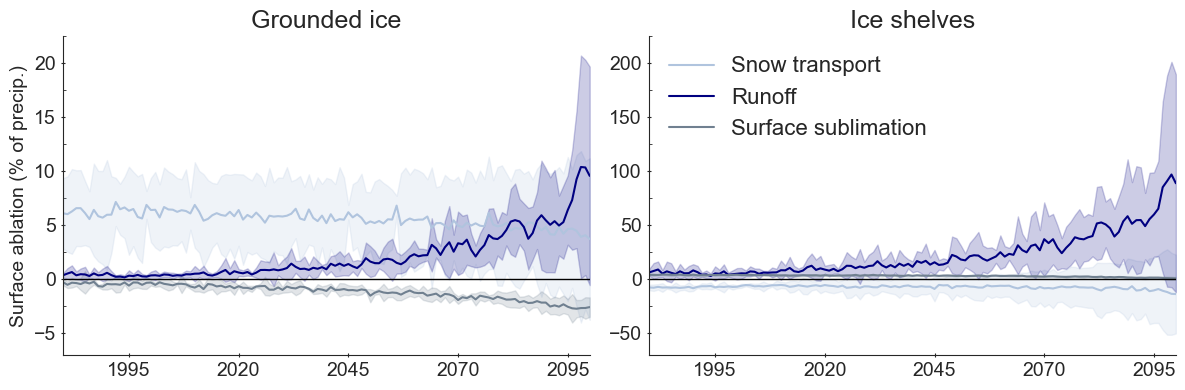

In [11]:
COMPONENTS = {"Snow transport": "lightsteelblue",
              "Runoff": "navy",
              "Surface sublimation": "slategrey"}
REGIONS = {"Grounded ice": (grd_msk, (-7, 22.5)),
           "Ice shelves": (shf_msk, (-70, 225))}
SPREAD = 1.64


def integrate(ds, variables, mask):
    """Spatial integral over the masked area, Gt yr-1."""
    factor = RESOLUTION ** 2 / 1e12
    return {v: ((flat(ds[v]) * mask.values).sum(dim=["X", "Y"]) * factor).to_series()
            for v in variables}


def relative_ablation(ref, drift, mask):
    n = integrate(ref, ["SF", "RF"], mask)
    d = integrate(drift, ["SF", "RF", "ER", "RU", "SU"], mask)
    precip = n["SF"] + n["RF"]
    return pd.DataFrame({
        "Snow transport": (precip - (d["SF"] + d["RF"] - d["ER"])) / precip * 100,
        "Runoff": d["RU"] / precip * 100,
        "Surface sublimation": d["SU"] / precip * 100,
    })


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (title, (mask, ylim)) in zip(axes, REGIONS.items()):
    tables = {m: relative_ablation(NDS[m], DS[m], mask) for m in MODELS}
    for component, color in COMPONENTS.items():
        df = pd.DataFrame({m: t[component] for m, t in tables.items()})
        mean, std = df.mean(axis=1), df.std(axis=1)
        mean.plot(ax=ax, color=color, label=component)
        ax.fill_between(YEARS, mean + SPREAD * std, mean - SPREAD * std,
                        color=color, alpha=0.2)

    ax.set_title(title, fontsize=18)
    ax.set_ylim(*ylim)
    ax.set_xlabel("")
    ax.axhline(color="black", lw=1)
    ax.tick_params(axis="both", labelsize=14)
    ax.yaxis.set_minor_locator(AutoMinorLocator(n=2))
    ax.tick_params(axis="y", which="major", direction="inout", left=True, right=False)
    ax.tick_params(axis="y", which="minor", direction="in", left=True, right=False)
    ax.tick_params(axis="x", which="major", direction="inout", top=False, bottom=True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Surface ablation (% of precip.)", fontsize=14)
axes[1].set_ylabel("")
axes[1].legend(frameon=False, prop={"size": 16}, loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_surface_ablation.png", dpi=200, bbox_inches="tight")
plt.show()

### Figure 1b — climate quadrant

Reference-period (1981-2010) near-surface temperature ('TT') against net deposition
(SF - ER) per basin, over grounded ice. Quadrants are split at the
medians. 

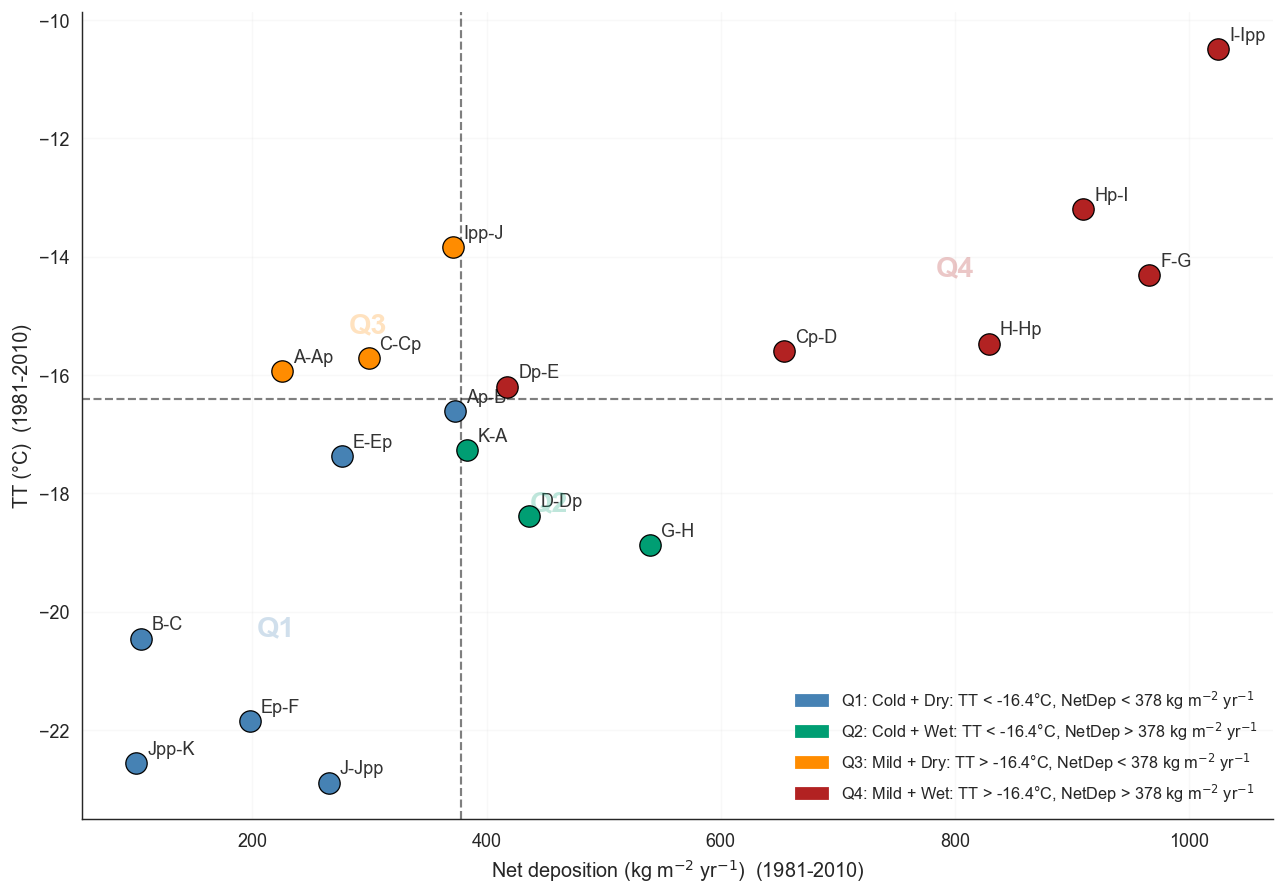

In [12]:
CLIM_BAND = (0, 1000)
UNIT = r"kg m$^{-2}$ yr$^{-1}$"

clim_mask = np.isfinite(SH) & (SH >= CLIM_BAND[0]) & (SH < CLIM_BAND[1])

rows = []
for basin in present:
    w = weights(basin, clim_mask)
    if not np.any(w > 0):
        continue
    for m in MODELS:
        ref = slice(REF0, REF1)
        rows.append({
            "basin": basin,
            "TT": np.nanmean(aw_mean(flat(DS[m]["TT"]).sel(TIME=ref), w)),
            "netdep": np.nanmean(aw_mean(flat(DS[m]["SF"] - DS[m]["ER"]).sel(TIME=ref), w)),
        })

climate = pd.DataFrame(rows).groupby("basin")[["TT", "netdep"]].mean()
med_TT = climate["TT"].median()
med_ND = climate["netdep"].median()

QUADRANTS = {
    "Q1": {"label": f"Cold + Dry: TT < {med_TT:.1f}°C, NetDep < {med_ND:.0f} {UNIT}",
           "color": "steelblue", "basins": []},
    "Q2": {"label": f"Cold + Wet: TT < {med_TT:.1f}°C, NetDep > {med_ND:.0f} {UNIT}",
           "color": "#009E73", "basins": []},
    "Q3": {"label": f"Mild + Dry: TT > {med_TT:.1f}°C, NetDep < {med_ND:.0f} {UNIT}",
           "color": "darkorange", "basins": []},
    "Q4": {"label": f"Mild + Wet: TT > {med_TT:.1f}°C, NetDep > {med_ND:.0f} {UNIT}",
           "color": "firebrick", "basins": []},
}

quadrant = {}
for basin, row in climate.iterrows():
    cold, dry = row["TT"] < med_TT, row["netdep"] < med_ND
    q = "Q1" if (cold and dry) else "Q2" if cold else "Q3" if dry else "Q4"
    quadrant[basin] = q
    QUADRANTS[q]["basins"].append(basin)

fig, ax = plt.subplots(figsize=(10, 7), dpi=130)

for basin, row in climate.iterrows():
    color = QUADRANTS[quadrant[basin]]["color"]
    ax.scatter(row["netdep"], row["TT"], s=140, color=color,
               edgecolor="black", lw=0.7, zorder=4)
    ax.annotate(basin, xy=(row["netdep"], row["TT"]), xytext=(6, 5),
                textcoords="offset points", fontsize=10, color="0.2")

ax.axvline(med_ND, color="black", lw=1.2, ls="--", alpha=0.5)
ax.axhline(med_TT, color="black", lw=1.2, ls="--", alpha=0.5)

for key, q in QUADRANTS.items():
    if not q["basins"]:
        continue
    sub = climate.loc[q["basins"]]
    ax.text(sub["netdep"].mean(), sub["TT"].mean(), key, fontsize=16,
            color=q["color"], ha="center", va="center", alpha=0.25, fontweight="bold")

ax.legend(handles=[Patch(color=q["color"], label=f"{k}: {q['label']}")
                   for k, q in QUADRANTS.items() if q["basins"]],
          frameon=False, fontsize=9, loc="lower right")
ax.set_xlabel(f"Net deposition ({UNIT})  (1981-2010)", fontsize=11)
ax.set_ylabel("TT (°C)  (1981-2010)", fontsize=11)
ax.grid(alpha=0.12)
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_climate_quadrant.png", dpi=200, bbox_inches="tight")
plt.show()

### Figure snow transport (wind-driven snow) vs. runoff, Here's for B-C and I-Ipp (Extended Data)

Relative ablation against basin warming, one row per forcing model, grounded ice
in the 350-700 m band. Bands are the 95% and 99% confidence intervals on a
degree-2 fit.

This base is used for fig 1c (split by 50 m step to define tbe elevation band where the transition happens)

MAR-CNRM   B-C     T_cross(fit) = +1.67 °C
MAR-CNRM   I-Ipp   T_cross(fit) = -1.46 °C
MAR-IPSL   B-C     T_cross(fit) = +2.02 °C
MAR-IPSL   I-Ipp   T_cross(fit) = +0.80 °C
MAR-MPI    B-C     T_cross(fit) = +1.37 °C
MAR-MPI    I-Ipp   T_cross(fit) = +2.37 °C
MAR-UKESM  B-C     T_cross(fit) = +2.21 °C
MAR-UKESM  I-Ipp   T_cross(fit) = -2.01 °C


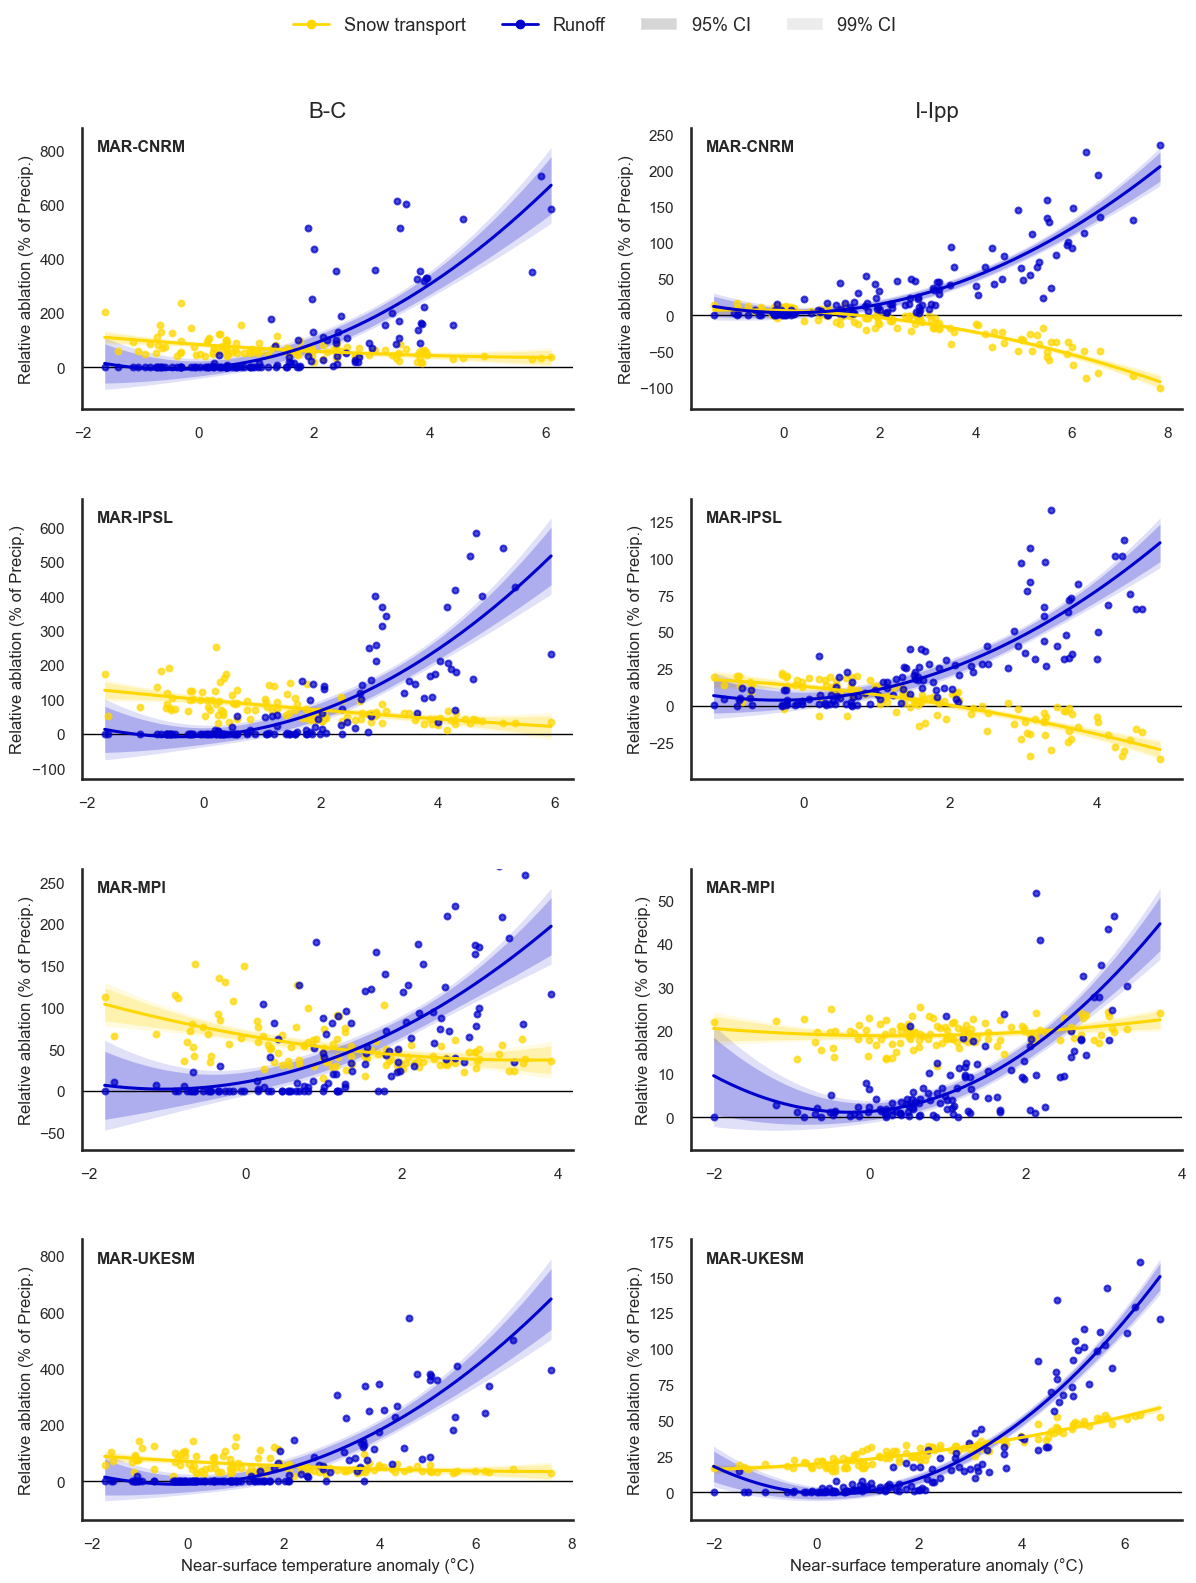

In [ ]:
PANEL_BASINS = ["B-C", "I-Ipp"]
DEG = 2
Y_QUANTILE = 92           # y-limits clip 
N_FIT = 200
COLORS = {"Snow transport": "gold", "Runoff": "mediumblue"}

sns.set_context("talk")   


def fit_ci(x, y, deg=DEG, n=N_FIT):
    """Polynomial fit with 95% and 99% confidence bands."""
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < deg + 3:
        return None
    xo, yo = x[ok], y[ok]
    X = np.vander(xo, deg + 1)
    beta = np.linalg.lstsq(X, yo, rcond=None)[0]
    dof = len(xo) - (deg + 1)
    resid_var = np.sum((yo - X @ beta) ** 2) / dof
    cov = resid_var * np.linalg.inv(X.T @ X)
    xs = np.linspace(np.nanmin(xo), np.nanmax(xo), n)
    Xs = np.vander(xs, deg + 1)
    ys = Xs @ beta
    se = np.sqrt(np.sum((Xs @ cov) * Xs, axis=1))
    return (xs, ys,
            ys - stats.t.ppf(0.975, dof) * se, ys + stats.t.ppf(0.975, dof) * se,
            ys - stats.t.ppf(0.995, dof) * se, ys + stats.t.ppf(0.995, dof) * se)


def curve_crossing(fit_er, fit_ru):
    
    if fit_er is None or fit_ru is None:
        return np.nan
    xs, diff = fit_er[0], fit_ru[1] - fit_er[1]
    if diff[0] > 0:
        return xs[0]
    idx = np.where((diff[:-1] <= 0) & (diff[1:] > 0))[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    return xs[i] + (xs[i + 1] - xs[i]) * (-diff[i]) / (diff[i + 1] - diff[i])


fig, axs = plt.subplots(len(MODELS), len(PANEL_BASINS), figsize=(12.5, 16))

for r, m in enumerate(MODELS):
    tta = tt_anomaly(DS[m])
    precip = flat(NDS[m]["SF"]) + flat(NDS[m]["RF"])
    netdep = flat(DS[m]["SF"]) + flat(DS[m]["RF"]) - flat(DS[m]["ER"])
    rel = {"Snow transport": 100.0 * (precip - netdep) / precip,
           "Runoff": 100.0 * flat(DS[m]["RU"]) / precip}

    for c, basin in enumerate(PANEL_BASINS):
        ax = axs[r, c]
        w = weights(basin)
        x = aw_mean(tta, w)
        y = {k: aw_mean(v, w) for k, v in rel.items()}

        fits = {}
        for name, color in COLORS.items():
            ax.scatter(x, y[name], s=18, color=color, alpha=0.7, zorder=3)
            fits[name] = fit_ci(x, y[name])
            if fits[name] is None:
                continue
            xs, ys, lo95, hi95, lo99, hi99 = fits[name]
            ax.fill_between(xs, lo99, hi99, color=color, alpha=0.12, lw=0, zorder=2)
            ax.fill_between(xs, lo95, hi95, color=color, alpha=0.22, lw=0, zorder=2)
            ax.plot(xs, ys, color=color, lw=2.2, zorder=4)

        pool = np.concatenate([v[np.isfinite(v)] for v in y.values()])
        band_lo = min(np.nanpercentile(pool, 100 - Y_QUANTILE),
                      min(np.nanmin(f[4]) for f in fits.values()), 0.0)
        band_hi = max(np.nanpercentile(pool, Y_QUANTILE),
                      max(np.nanmax(f[5]) for f in fits.values()))
        pad = 0.08 * (band_hi - band_lo)
        ax.set_ylim(band_lo - pad, band_hi + pad)

        tc = curve_crossing(fits["Snow transport"], fits["Runoff"])
        ax.axhline(0, color="black", lw=1)
        ax.text(0.03, 0.96, LONG_NAME[m], transform=ax.transAxes,
                fontsize=11.5, fontweight="bold", va="top")
        ax.xaxis.set_major_locator(MultipleLocator(2))
        ax.tick_params(axis="both", labelsize=11)
        ax.set_ylabel("Relative ablation (% of Precip.)", fontsize=12)
        if r == 0:
            ax.set_title(basin, fontsize=16, pad=8)
        if r == len(MODELS) - 1:
            ax.set_xlabel("Near-surface temperature anomaly (°C)", fontsize=12)

        print(f"{LONG_NAME[m]:10s} {basin:6s}  T_cross(fit) = "
              f"{'—' if not np.isfinite(tc) else format(tc, '+.2f')} °C")

fig.legend(handles=[plt.Line2D([0], [0], color=c, lw=2, marker="o", ms=6, label=k)
                    for k, c in COLORS.items()] +
                   [Patch(facecolor="0.55", alpha=0.35, label="95% CI"),
                    Patch(facecolor="0.55", alpha=0.16, label="99% CI")],
           loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 1.0), fontsize=13)
plt.subplots_adjust(left=0.09, right=0.97, top=0.92, bottom=0.05, wspace=0.24, hspace=0.32)
sns.despine()
fig.savefig(FIG_DIR / "fig3_transition_bands.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
sns.set_context("notebook")

### Table T_CROSS values

Warming at which runoff overtakes snow transport (wind-driven snow),
per basin and model, grounded ice 350-700 m. Crossing beyond the
simulated range (>2100) are `extrapolated` these values are marked in bold on the figure 2b.

In [ ]:
DEG = 2
T_EXTRAP_MAX = 12.0
OUT = TAB_DIR / "T_CROSS_table_350_700m_polyfit.csv"


def poly_cross(x, y_er, y_ru, deg=DEG, extrap_max=T_EXTRAP_MAX):
   
    ok_er = np.isfinite(x) & np.isfinite(y_er)
    ok_ru = np.isfinite(x) & np.isfinite(y_ru)
    if ok_er.sum() < deg + 5 or ok_ru.sum() < deg + 5:
        return np.nan, "no_cross"

    p_er = np.polyfit(x[ok_er], y_er[ok_er], deg)
    p_ru = np.polyfit(x[ok_ru], y_ru[ok_ru], deg)
    p_diff = p_ru - p_er                     

    x_min = max(np.nanmin(x[ok_er]), np.nanmin(x[ok_ru]))
    x_data_max = min(np.nanmax(x[ok_er]), np.nanmax(x[ok_ru]))
    x_max = max(x_data_max, extrap_max)

    roots = sorted(float(r.real) for r in np.roots(p_diff)
                   if abs(r.imag) < 1e-7 and x_min <= r.real <= x_max)
    for root in roots:
        if np.polyval(np.polyder(p_diff), root) > 0:
            return root, "data" if root <= x_data_max else "extrapolated"
    return np.nan, "no_cross"


rows = []
for m in MODELS:
    tta = tt_anomaly(DS[m])
    precip = flat(NDS[m]["SF"]) + flat(NDS[m]["RF"])
    netdep = flat(DS[m]["SF"]) + flat(DS[m]["RF"]) - flat(DS[m]["ER"])
    rel_er = xr.where(precip > 0, 100.0 * (precip - netdep) / precip, np.nan)
    rel_ru = xr.where(precip > 0, 100.0 * flat(DS[m]["RU"]) / precip, np.nan)

    for basin in BASINS:
        w = weights(basin)
        if not np.any(w > 0):
            rows.append({"basin": basin, "model": m, "T_CROSS": np.nan, "flag": "no_cells"})
            continue
        tcross, flag = poly_cross(aw_mean(tta, w), aw_mean(rel_er, w), aw_mean(rel_ru, w))
        rows.append({"basin": basin, "model": m, "T_CROSS": tcross, "flag": flag})
    print(f"{m}: done")

long_tcross = pd.DataFrame(rows)

df_tcross = long_tcross.pivot(index="basin", columns="model", values="T_CROSS")
df_tcross = df_tcross.reindex(index=BASINS, columns=list(MODELS))
df_tcross["Mean"] = df_tcross[list(MODELS)].mean(axis=1)
df_tcross["Min"] = df_tcross[list(MODELS)].min(axis=1)
df_tcross["Max"] = df_tcross[list(MODELS)].max(axis=1)
flags = long_tcross.pivot(index="basin", columns="model", values="flag").reindex(BASINS)
for m in MODELS:
    df_tcross[f"{m}_flag"] = flags[m]

df_tcross = df_tcross.reset_index().rename(columns={"basin": "Basin"})
df_tcross.to_csv(OUT, index=False, float_format="%.3f")
print(f"\nsaved {OUT}")
display(df_tcross[["Basin"] + list(MODELS) + ["Mean", "Min", "Max"]].round(2))

CNRM: done
IPSL: done
MPI: done
UKM: done

saved tables/T_CROSS_table_350_700m_polyfit.csv


model,Basin,CNRM,IPSL,MPI,UKM,Mean,Min,Max
0,A-Ap,4.06,4.26,3.22,5.14,4.17,3.22,5.14
1,Ap-B,2.58,2.35,1.53,3.64,2.52,1.53,3.64
2,B-C,1.67,2.02,1.37,2.21,1.82,1.37,2.21
3,C-Cp,2.97,3.27,2.32,4.51,3.27,2.32,4.51
4,Cp-D,2.45,2.51,2.40,4.55,2.98,2.40,4.55
5,D-Dp,4.19,3.72,4.99,6.20,4.77,3.72,6.20
6,Dp-E,0.98,0.18,0.04,1.01,0.55,0.04,1.01
7,E-Ep,4.34,3.44,4.56,4.39,4.18,3.44,4.56
8,Ep-F,2.04,3.54,NaN,NaN,2.79,2.04,3.54
9,F-G,3.92,5.40,4.66,NaN,4.66,3.92,5.40


### Table T_MOA values

Warming at which liquid water production reaches 70% of net accumulation, adapted from van Wessem et al., 2023. `pooled` fits all four models together; `mean`/`std`/`range`
extrapolated values (>2100) are in bold on the figure 2a.

In [17]:
OUT = TAB_DIR / "TMOA_table_350_700m.csv"

records = []
for basin in present:
    w = weights(basin)
    pooled_x, pooled_num, pooled_den = [], [], []

    for m in MODELS:
        f = FIELDS[m]
        x = aw_mean(f["TT_ano"], w)
        num = aw_mean(f["NUM"], w)
        den = aw_mean(f["DEN"], w)
        ok = np.isfinite(x) & np.isfinite(num) & np.isfinite(den)
        if ok.sum() < 10:
            continue

        fit = fit_wessem(x[ok], num[ok], den[ok])
        records.append({"basin": basin, "model": m,
                        "T_MOA": fit["T_moa"] if fit else np.nan,
                        "x_max": float(np.nanmax(x))})
        pooled_x.extend(x[ok])
        pooled_num.extend(num[ok])
        pooled_den.extend(den[ok])

    pooled = fit_wessem(np.array(pooled_x), np.array(pooled_num),
                        np.array(pooled_den)) if len(pooled_x) >= 10 else None
    records.append({"basin": basin, "model": "pooled",
                    "T_MOA": pooled["T_moa"] if pooled else np.nan, "x_max": np.nan})

long_tmoa = pd.DataFrame(records)

df_tmoa = (long_tmoa.pivot_table(index="basin", columns="model", values="T_MOA",
                                 aggfunc="first")
           .reindex(index=present, columns=list(MODELS) + ["pooled"]))
per_model = list(MODELS)
df_tmoa["n_reach"] = df_tmoa[per_model].notna().sum(axis=1)
df_tmoa["mean"] = df_tmoa[per_model].mean(axis=1).round(2)
df_tmoa["std"] = df_tmoa[per_model].std(axis=1).round(2)
df_tmoa["min"] = df_tmoa[per_model].min(axis=1).round(2)
df_tmoa["max"] = df_tmoa[per_model].max(axis=1).round(2)
df_tmoa["range"] = (df_tmoa["max"] - df_tmoa["min"]).round(2)

df_tmoa = df_tmoa.rename_axis(None, axis=1).reset_index()
df_tmoa.to_csv(OUT, index=False, float_format="%.3f")
print(f"T_MOA (°C above 1981-2010) at MOA = {MOA_THRESHOLD}, "
      f"{BAND[0]}-{BAND[1]} m grounded ice")
print(f"basins where all {len(MODELS)} models reach the threshold: "
      f"{int((df_tmoa['n_reach'] == len(MODELS)).sum())} of {len(present)}")
print(f"saved {OUT}\n")
display(df_tmoa.round(2).set_index("basin"))

T_MOA (°C above 1981-2010) at MOA = 0.7, 350-700 m grounded ice
basins where all 4 models reach the threshold: 18 of 18
saved tables/TMOA_table_350_700m.csv



,CNRM,IPSL,MPI,UKM,pooled,n_reach,mean,std,min,max,range
basin,,,,,,,,,,,
A-Ap,4.16,4.54,4.09,5.40,4.73,4,4.55,0.60,4.09,5.40,1.31
Ap-B,3.87,3.62,3.55,5.54,4.52,4,4.14,0.94,3.55,5.54,1.99
B-C,1.59,2.10,2.47,2.33,1.98,4,2.12,0.39,1.59,2.47,0.88
C-Cp,2.87,3.41,2.88,5.03,3.83,4,3.55,1.02,2.87,5.03,2.16
Cp-D,4.35,4.34,4.57,5.92,5.13,4,4.80,0.75,4.34,5.92,1.58
D-Dp,4.36,3.43,4.77,5.70,4.74,4,4.56,0.94,3.43,5.70,2.27
Dp-E,4.50,3.54,3.42,5.12,4.45,4,4.15,0.81,3.42,5.12,1.70
E-Ep,4.37,3.31,5.12,4.05,4.05,4,4.21,0.75,3.31,5.12,1.81
Ep-F,6.95,7.87,7.13,8.16,7.49,4,7.53,0.58,6.95,8.16,1.21


## Figure 2 T_MOA and T_CROSS spatial maps

Per-pixel warming at which each threshold is first crossed, averaged over the
four models. Both maps share the colour scale: blue means the pixel has already
crossed in the reference climate, red is warming still needed. The purple
contours mark the 350 and 700 m band where the chnage in the ablation regime happens (wind-driven snow > to meltwater runoff). 


T_MOA  CNRM   crossed  2618 px   already exceeded   332 px   median +2.96
T_MOA  IPSL   crossed  2362 px   already exceeded   259 px   median +2.31
T_MOA  MPI    crossed  1428 px   already exceeded   336 px   median +1.33
T_MOA  UKM    crossed  2221 px   already exceeded   189 px   median +4.53
T_CROSS CNRM   crossed  2394 px   already exceeded   264 px   median +4.16
T_CROSS IPSL   crossed  2176 px   already exceeded   260 px   median +3.07
T_CROSS MPI    crossed  1477 px   already exceeded   215 px   median +1.27
T_CROSS UKM    crossed  2000 px   already exceeded   150 px   median +4.32


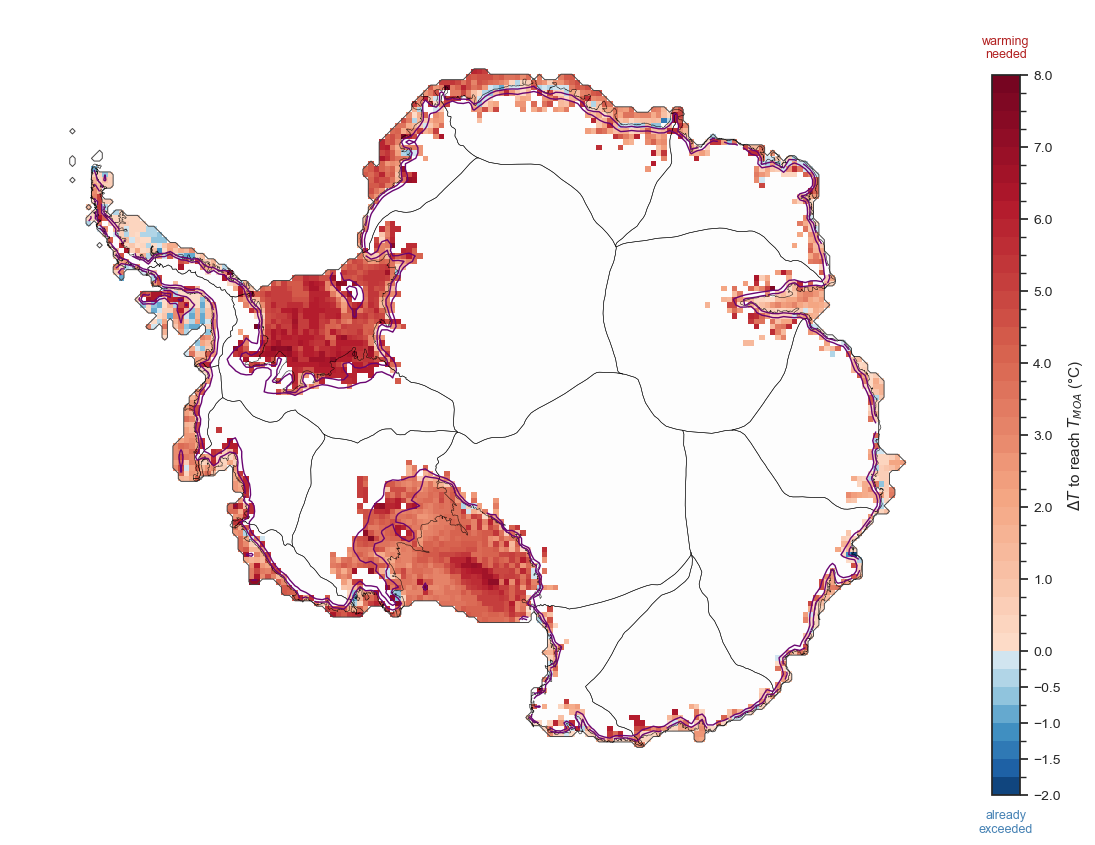

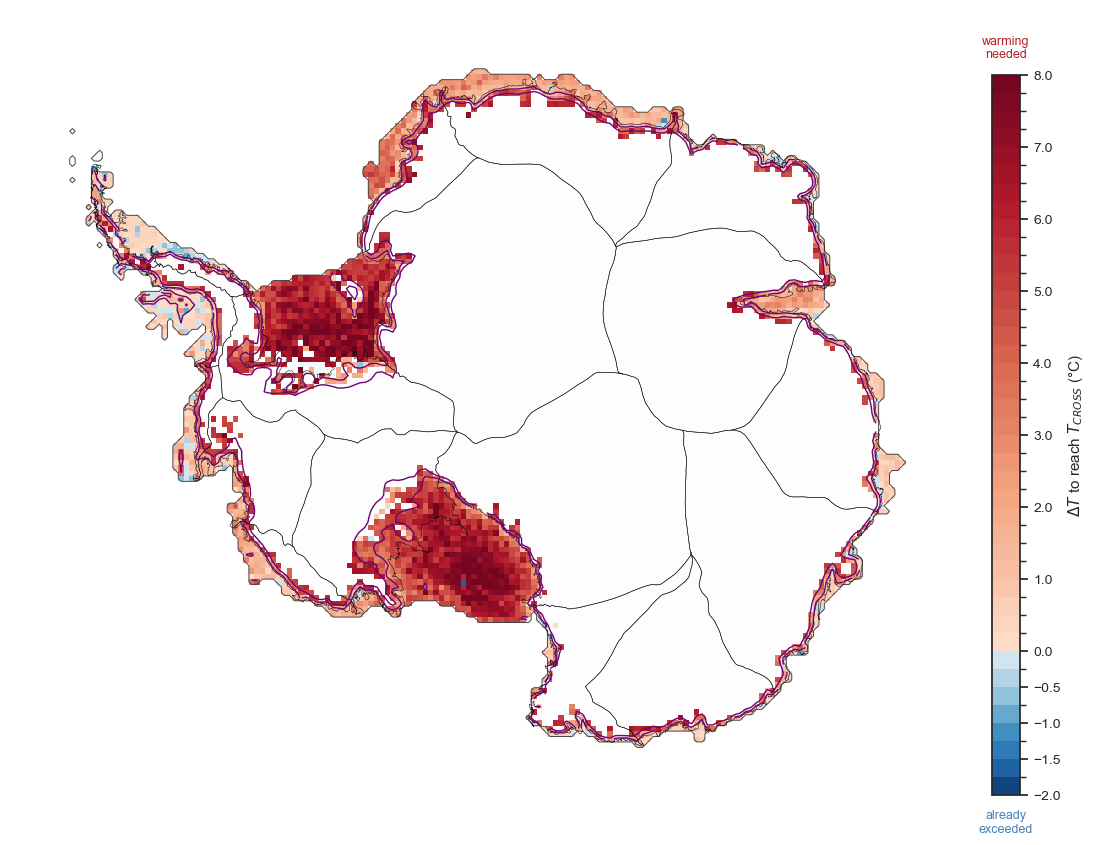

In [ ]:
SMOOTH_TCROSS = 0          # years of centred rolling mean before the crossing test
TCROSS_RU_MIN = 1.0        # kg m-2 yr-1, ignores negligible runoff
TMOA_MODE = "anomaly"      # "anomaly" (comparable with T_CROSS) or "absolute"
LABEL_BASINS = False


def tt_at_moa(ds, mode="anomaly", threshold=MOA_THRESHOLD, smooth=0):
    moa = moa_ratio(ds)
    tt = flat(ds["TT"])
    if mode == "anomaly":
        tt = tt - tt.sel(TIME=slice(REF0, REF1)).mean("TIME")
    if smooth:
        moa = moa.rolling(TIME=smooth, center=True, min_periods=1).mean()
        tt = tt.rolling(TIME=smooth, center=True, min_periods=1).mean()
    moa, tt = moa.load(), tt.load()
    exceed = moa >= threshold
    return tt.isel(TIME=exceed.argmax("TIME")).where(exceed.any("TIME")).squeeze(drop=True)


def tt_at_tcross(dsD, dsN, ru_min=TCROSS_RU_MIN, smooth=SMOOTH_TCROSS):
    """Warming at which runoff first overtakes snow transport (wind-driven snow), per pixel."""
    ru = flat(dsD["RU"])
    precip = flat(dsN["SF"]) + flat(dsN["RF"])
    transport = precip - (flat(dsD["SF"]) + flat(dsD["RF"]) - flat(dsD["ER"]))
    tt = tt_anomaly(dsD)
    if smooth:
        ru, transport, tt = (d.rolling(TIME=smooth, center=True, min_periods=1).mean()
                             for d in (ru, transport, tt))
    ru, transport, precip, tt = ru.load(), transport.load(), precip.load(), tt.load()
    exceed = (ru > transport) & (ru > ru_min) & (precip > 0)
    return tt.isel(TIME=exceed.argmax("TIME")).where(exceed.any("TIME")).squeeze(drop=True)


def ensemble_mean(fields, name=""):
    stack = []
    for m, field in fields.items():
        a = np.asarray(field.transpose("Y", "X"), dtype=float)
        a[~ais_mask] = np.nan
        a[lsm] = np.nan
        stack.append(a)
        fin = np.isfinite(a)
        print(f"{name}{m:5s}  crossed {fin.sum():5d} px   "
              f"already exceeded {int((a[fin] < 0).sum()):5d} px   "
              f"median {np.nanmedian(a):+.2f}")
    return np.nanmean(np.stack(stack), axis=0)



_base = plt.get_cmap("RdBu_r")
_neg = [_base(0.04 + 0.36 * i / 7) for i in range(8)]
_pos = [_base(0.60 + 0.38 * i / 31) for i in range(32)]
CMAP_DT = LinearSegmentedColormap.from_list("dt_div", _neg + _pos, N=40)
CMAP_DT.set_bad("none")
NORM_DT = mpl.colors.BoundaryNorm(
    np.concatenate([np.linspace(-2, 0, 9), np.linspace(0, 8, 33)[1:]]), ncolors=40)
TICKS_DT = np.concatenate([np.arange(-2, 0, 0.5), np.arange(0, 9, 1)])

CMAP_ABS = plt.get_cmap("Blues", 40).copy()
CMAP_ABS.set_bad("none")
NORM_ABS = mpl.colors.BoundaryNorm(np.linspace(-30, 0, 41), ncolors=40)
TICKS_ABS = np.arange(-30, 1, 5)


def draw_map(field, cmap, norm, ticks, label, out, annotate=True):
    fig, ax = plt.subplots(figsize=(13, 12))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.pcolormesh(x2m, y2m, np.where(GROUND, 1.0, np.nan),
                  shading="auto", cmap="Greys", vmin=0, vmax=8, alpha=0.12)
    ax.pcolormesh(x2m, y2m, np.where(SHELF, 1.0, np.nan),
                  shading="auto", cmap="Blues", vmin=0, vmax=4, alpha=0.18)

    finite = np.isfinite(field)
    pm = ax.pcolormesh(x2m, y2m, ma.array(field, mask=~finite),
                       cmap=cmap, norm=norm, shading="auto", rasterized=True, zorder=3)

    ax.contour(x2m, y2m, ICE.astype(float), levels=[0.5],
               colors="#464444", linewidths=0.7, zorder=4)
    ax.contour(x2m, y2m, topo_grd, levels=list(BAND),
               colors="#6a0572", linewidths=1.0, zorder=9)
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.4, alpha=0.85, zorder=5)
    if LABEL_BASINS:
        for _, row in gdf.iterrows():
            c = row.geometry.centroid
            ax.text(c.x, c.y, row["Subregion"], fontsize=6, ha="center", va="center",
                    color="black", fontweight="bold", zorder=6)

    cax = fig.add_axes([0.88, 0.18, 0.022, 0.60])
    cb = fig.colorbar(pm, cax=cax, ticks=ticks)
    cb.set_label(label, fontsize=11)
    cb.ax.tick_params(labelsize=10)
    if annotate:
        cb.ax.text(0.5, 1.02, "warming\nneeded", ha="center", va="bottom",
                   fontsize=9, transform=cb.ax.transAxes, color="firebrick")
        cb.ax.text(0.5, -0.02, "already\nexceeded", ha="center", va="top",
                   fontsize=9, transform=cb.ax.transAxes, color="steelblue")

    ax.set_aspect("equal")
    ax.axis("off")
    plt.subplots_adjust(right=0.86, top=0.97, bottom=0.03)
    fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


tmoa_map = ensemble_mean({m: tt_at_moa(DS[m], mode=TMOA_MODE) for m in MODELS}, "T_MOA  ")
tcross_map = ensemble_mean({m: tt_at_tcross(DS[m], NDS[m]) for m in MODELS}, "T_CROSS ")

if TMOA_MODE == "anomaly":
    draw_map(tmoa_map, CMAP_DT, NORM_DT, TICKS_DT,
             r"$\Delta T$ to reach $T_{MOA}$ (°C)", FIG_DIR / "fig4a_tmoa_map.png")
else:
    draw_map(tmoa_map, CMAP_ABS, NORM_ABS, TICKS_ABS,
             f"Absolute TT at MOA = {MOA_THRESHOLD} (°C)",
             FIG_DIR / "fig4a_tmoa_map.png", annotate=False)

draw_map(tcross_map, CMAP_DT, NORM_DT, TICKS_DT,
         r"$\Delta T$ to reach $T_{CROSS}$ (°C)", FIG_DIR / "fig4b_tcross_map.png")

### Figure 3 effect of wind-driven on the MOA thresholds

T_MOA recomputed with the wind-driven scheme off (nDS here or mentioned nWDS in the paper), and the difference.

- DS:  MOA = (ME + RF) / (SF - ER - SU)  wind-driven scheme on  (WDS)
- nDS: MOA = (ME + RF) / (SF - SU)       wind-drivem scheme off (nWDS)

In [20]:
COMMON_TREF = False        # True measures both runs against the DS reference climate
RISK_THRESHOLD = 6.0 

def threshold_run(run):
    """Per-basin, per-model T_MOA and the reference-to-future change in each MOA term."""
    rows = []
    for basin in present:
        w = weights(basin)
        for m in MODELS:
            ds = DS[m] if run == "DS" else NDS[m]
            x = aw_mean(tt_anomaly(ds, ref=DS[m] if COMMON_TREF else None), w)
            num, den = moa_num(ds), moa_den(ds, run)
            y_num, y_den = aw_mean(num, w), aw_mean(den, w)
            ok = np.isfinite(x) & np.isfinite(y_num) & np.isfinite(y_den)

            fit = fit_wessem(x[ok], y_num[ok], y_den[ok]) if ok.sum() >= 10 else None
            change = {}
            for key, term in (("dA", den), ("dME", num)):
                ref = np.nanmean(aw_mean(term.sel(TIME=slice(REF0, REF1)), w))
                fut = np.nanmean(aw_mean(term.sel(TIME=slice(FUT0, FUT1)), w))
                change[key] = fut - ref

            rows.append({"run": run, "basin": basin, "model": m,
                         "T_MOA": fit["T_moa"] if fit else np.nan, **change})

    long = pd.DataFrame(rows)
    t = long.groupby("basin")["T_MOA"]
    summary = pd.DataFrame({"T_MOA_mean": t.mean(), "T_MOA_min": t.min(),
                            "T_MOA_max": t.max(), "n_reach": t.count()}).reset_index()
    summary["risk"] = np.where(
        (summary["n_reach"] == len(MODELS)) & (summary["T_MOA_max"] < RISK_THRESHOLD),
        "At risk", "Not at risk")
    return long, summary.set_index("basin").reindex(present).reset_index()


long_DS, df_DS = threshold_run("DS")
long_nDS, df_nDS = threshold_run("nDS")

for run, df in (("DS", df_DS), ("nDS", df_nDS)):
    print(f"{run:4s} at risk: {int((df['risk'] == 'At risk').sum())} of {len(df)} basins")

long_DS.to_csv(TAB_DIR / "TMOA_DS_per_model.csv", index=False)
long_nDS.to_csv(TAB_DIR / "TMOA_nDS_per_model.csv", index=False)

DS   at risk: 10 of 18 basins
nDS  at risk: 10 of 18 basins


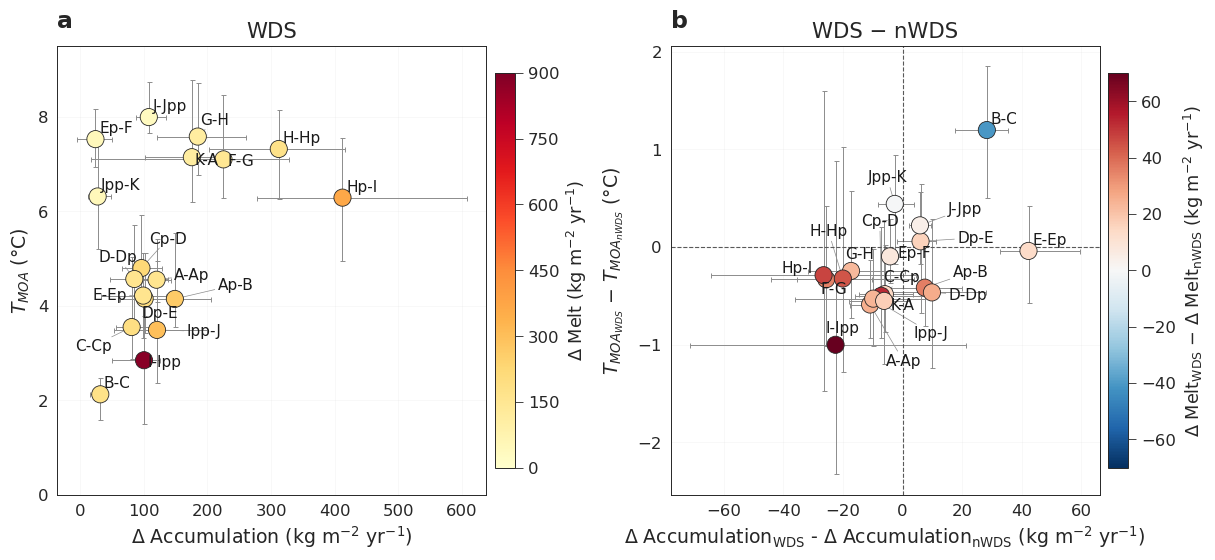

,basin,dA_mean,dA_min,dA_max,TMOA_mean,TMOA_min,TMOA_max,dME_mean,n_models
0,I-Ipp,-22.468,-71.231,21.373,-1.002,-2.328,0.876,70.076,4
1,A-Ap,-10.872,-17.750,-3.609,-0.590,-0.934,-0.130,25.666,4
2,K-A,-6.165,-17.850,2.613,-0.553,-1.200,0.276,17.328,4
3,Ipp-J,-9.826,-36.125,7.618,-0.530,-1.020,-0.017,23.954,4
4,Cp-D,-7.145,-15.925,7.708,-0.501,-0.929,0.200,52.186,4
5,C-Cp,-5.932,-14.524,3.514,-0.484,-0.867,0.023,14.413,4
6,D-Dp,9.873,-5.242,28.149,-0.466,-1.244,0.291,26.107,4
7,Ap-B,7.507,-5.604,20.011,-0.417,-0.812,0.070,36.066,4
8,F-G,-25.611,-35.568,-10.118,-0.331,-1.018,0.421,34.515,4
9,H-Hp,-20.033,-44.114,3.795,-0.324,-1.285,1.020,44.224,4


In [21]:
SAVE_FIG = True
SCALE = 1.7
FIG_W, FIG_H = 180 / 25.4 * SCALE, 82 / 25.4 * SCALE
FS_TICK, FS_AX, FS_TITLE, FS_LAB, FS_PANEL, FS_CB = (s * SCALE for s in (7, 8, 9, 6.5, 10, 7.5))
MSIZE = 90 * SCALE
VMIN, VMAX = 0, 900        # left-panel colour range, kg m-2 yr-1

plt.rcParams["font.family"] = "DejaVu Sans"

try:
    from adjustText import adjust_text
except ImportError:
    adjust_text = None
    print("adjustText not installed — basin labels are left where they fall")


def with_errors(t):
    t["xerr_left"] = t["dA_mean"] - t["dA_min"]
    t["xerr_right"] = t["dA_max"] - t["dA_mean"]
    t["yerr_low"] = t["TMOA_mean"] - t["TMOA_min"]
    t["yerr_high"] = t["TMOA_max"] - t["TMOA_mean"]
    return t


def absolute_table(summary, long):
    spread = long.groupby("basin").agg(dA_mean=("dA", "mean"), dA_min=("dA", "min"),
                                       dA_max=("dA", "max"), dME_mean=("dME", "mean"))
    t = summary.merge(spread.reset_index(), on="basin").rename(
        columns={"T_MOA_mean": "TMOA_mean", "T_MOA_min": "TMOA_min", "T_MOA_max": "TMOA_max"})
    return with_errors(t)


def difference_table(long_ds, long_nds):
    """DS - nDS per model first, then aggregated per basin."""
    keep = ["basin", "model", "T_MOA", "dA", "dME"]
    d = long_ds[keep].merge(long_nds[keep], on=["basin", "model"], suffixes=("_DS", "_nDS"))
    d["dTMOA"] = d["T_MOA_DS"] - d["T_MOA_nDS"]
    d["ddA"] = d["dA_DS"] - d["dA_nDS"]
    d["ddME"] = d["dME_DS"] - d["dME_nDS"]
    t = d.groupby("basin").agg(
        TMOA_mean=("dTMOA", "mean"), TMOA_min=("dTMOA", "min"), TMOA_max=("dTMOA", "max"),
        dA_mean=("ddA", "mean"), dA_min=("ddA", "min"), dA_max=("ddA", "max"),
        dME_mean=("ddME", "mean"), n_models=("dTMOA", lambda s: int(np.isfinite(s).sum())),
    ).reset_index()
    return with_errors(t).dropna(subset=["TMOA_mean", "dA_mean"])


def draw_panel(ax, table, title, xlabel, cmap, norm, abs_ylim=False):
    for _, row in table.iterrows():
        ax.errorbar(row["dA_mean"], row["TMOA_mean"],
                    xerr=[[row["xerr_left"]], [row["xerr_right"]]],
                    yerr=[[row["yerr_low"]], [row["yerr_high"]]],
                    fmt="none", ecolor="0.55", elinewidth=0.7,
                    capsize=1.8, capthick=0.7, zorder=1)

    sc = ax.scatter(table["dA_mean"], table["TMOA_mean"], c=table["dME_mean"],
                    cmap=cmap, norm=norm, s=MSIZE, edgecolor="0.15",
                    linewidth=0.6, zorder=3)
    texts = [ax.text(x, y, b, fontsize=FS_LAB, color="0.1", zorder=4)
             for x, y, b in zip(table["dA_mean"], table["TMOA_mean"], table["basin"])]

    ax.set_title(title, fontsize=FS_TITLE, pad=6)
    ax.set_xlabel(xlabel, fontsize=FS_AX)
    ax.grid(alpha=0.18, linewidth=0.5)
    ax.tick_params(axis="both", labelsize=FS_TICK, width=0.6, length=3)
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
    if abs_ylim:
        ax.set_ylim(0, max(9.5, np.nanmax(table["TMOA_max"]) + 0.5))
    return sc, texts


plot_DS = absolute_table(df_DS, long_DS)
plot_diff = difference_table(long_DS, long_nDS)

norm_DS = Normalize(vmin=VMIN, vmax=VMAX)
cabs = float(np.nanmax(np.abs(plot_diff["dME_mean"])))
norm_diff = TwoSlopeNorm(vmin=-cabs, vcenter=0.0, vmax=cabs) if np.isfinite(cabs) and cabs > 0 \
    else TwoSlopeNorm(vmin=-1, vcenter=0.0, vmax=1)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), constrained_layout=True)

sc_DS, texts_DS = draw_panel(
    axes[0], plot_DS, "WDS", r"$\Delta$ Accumulation (kg m$^{-2}$ yr$^{-1}$)",
    "YlOrRd", norm_DS, abs_ylim=True)
axes[0].set_ylabel(r"$T_{MOA}$ (°C)", fontsize=FS_AX)

cb = fig.colorbar(sc_DS, ax=axes[0], fraction=0.046, pad=0.02)
cb.set_label(r"$\Delta$ Melt (kg m$^{-2}$ yr$^{-1}$)", fontsize=FS_CB)
cb.set_ticks(np.arange(VMIN, VMAX + 1, 150))
cb.ax.tick_params(labelsize=FS_TICK, width=0.6)
cb.outline.set_linewidth(0.7)

sc_diff, texts_diff = draw_panel(
    axes[1], plot_diff, "WDS − nWDS",
    r"$\Delta$ Accumulation$_{\mathrm{WDS}}$ - $\Delta$ Accumulation$_{\mathrm{nWDS}}$"
    r" (kg m$^{-2}$ yr$^{-1}$)",
    "RdBu_r", norm_diff)
axes[1].axhline(0, color="0.35", linestyle="--", linewidth=0.8, zorder=2)
axes[1].axvline(0, color="0.35", linestyle="--", linewidth=0.8, zorder=2)
axes[1].set_ylabel(r"$T_{MOA_{WDS}}$ $-$ $T_{MOA_{nWDS}}$ (°C)", fontsize=FS_AX, labelpad=8)

cb_diff = fig.colorbar(sc_diff, ax=axes[1], fraction=0.046, pad=0.02)
cb_diff.set_label(r"$\Delta$ Melt$_{\mathrm{WDS}}$ $-$ $\Delta$ Melt$_{\mathrm{nWDS}}$"
                  r" (kg m$^{-2}$ yr$^{-1}$)", fontsize=FS_CB)
cb_diff.ax.tick_params(labelsize=FS_TICK, width=0.6)
cb_diff.outline.set_linewidth(0.7)

for ax, letter in zip(axes, "ab"):
    ax.text(0.0, 1.03, letter, transform=ax.transAxes, fontsize=FS_PANEL,
            fontweight="bold", va="bottom", ha="left")

if adjust_text is not None:
    fig.canvas.draw()
    for ax, texts, table in ((axes[0], texts_DS, plot_DS), (axes[1], texts_diff, plot_diff)):
        adjust_text(texts, x=list(table["dA_mean"]), y=list(table["TMOA_mean"]), ax=ax,
                    arrowprops=dict(arrowstyle="-", color="0.55", lw=0.5),
                    expand=(1.2, 1.45), force_text=(0.45, 0.6), force_static=(0.25, 0.4),
                    min_arrow_len=5, max_move=(26, 26))

if SAVE_FIG:
    fig.savefig(FIG_DIR / "fig5_DS_effect_on_thresholds.png", dpi=300, bbox_inches="tight")
plt.show()

display(plot_diff[["basin", "dA_mean", "dA_min", "dA_max",
                   "TMOA_mean", "TMOA_min", "TMOA_max", "dME_mean", "n_models"]]
        .sort_values("TMOA_mean").round(3).reset_index(drop=True))